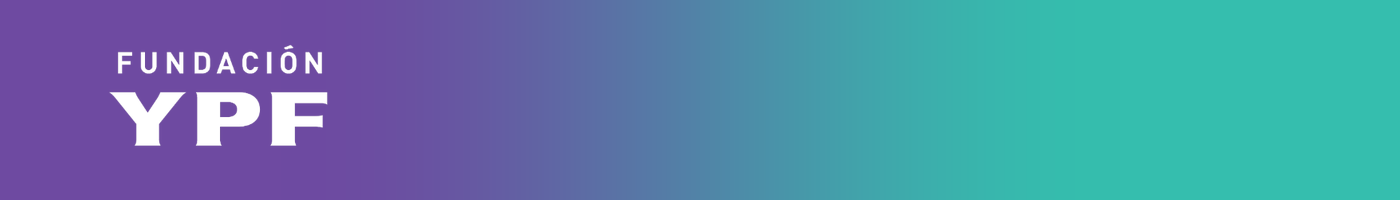

# Fundación YPF - Data Science


# Notebook 15: Tipos de algoritmos, aprendizaje supervisado y no supervisado

Esta notebook acompaña la **Clase 11 - Fundamentos del Machine Learning: tipos de algoritmos**. Retomamos el dataset de expectativa de vida que veníamos trabajando en el análisis exploratorio y lo usamos para responder una única pregunta: **qué tipo de tarea de Machine Learning tenemos delante y cómo se prepara el dataset para cada una**.

Todavía no vamos a entrenar ningún modelo. Eso empieza en la Clase 12, con la Notebook 16.

## Índice

- **Parte 0:** Preparación del entorno y carga de datos
- **Parte 1:** Repaso, exploración y limpieza mínima
- **Parte 2:** Datos etiquetados y datos no etiquetados
- **Parte 3:** Tarea supervisada de regresión
- **Parte 4:** Tarea supervisada de clasificación
- **Parte 5:** Tarea no supervisada de agrupamiento
- **Parte 6:** Cómo elijo el algoritmo
- **Parte 7:** Ejercicio para las salas de Zoom

## Datasets que se usan

| Archivo | Dónde se usa |
| --- | --- |
| `life_expectancy_data.csv` | Partes 1 a 6 |
| `clientes_mall.csv` | Parte 7 |
| `venta_autos.csv` | Parte 7 |


## Parte 0: Preparación del entorno y carga de datos

Antes de empezar, subí los tres archivos `.csv` de la carpeta de la clase al panel de archivos de Colab, o montá tu Google Drive. Si trabajás en Jupyter local, alcanza con dejar los `.csv` en la misma carpeta que esta notebook.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 30)
sns.set_theme(style='whitegrid')

print('pandas', pd.__version__)

pandas 3.0.3


In [4]:
# Si los archivos están en Google Drive, descomentá estas dos líneas
# from google.colab import drive
# drive.mount('/content/drive')

RUTA = 'C:/Users/gn_d4/Documents/GERMÁN/DATA SCIENCE/DATA SCIENCE/NOTEBOOKS/NOTEBOOKS 2026/life_expectancy_data.csv'

df = pd.read_csv(RUTA)
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,97,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


## Parte 1: Repaso, exploración y limpieza mínima

Esto ya lo vimos en las Notebooks 8 a 12. Lo repasamos rápido porque cualquier tarea de Machine Learning arranca acá: si no sabemos qué tiene el dataset, no podemos decidir qué algoritmo usar.


In [5]:
print('Filas y columnas:', df.shape)
df.info()

Filas y columnas: (2938, 22)
<class 'pandas.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   str    
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   str    
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Po

Los nombres de varias columnas vienen con espacios de más al principio o al final. Es un detalle chico que da errores molestos más adelante, así que lo limpiamos primero.


In [6]:
print('Antes:', df.columns.tolist()[:6])

df.columns = df.columns.str.strip()

print('Después:', df.columns.tolist()[:6])

Antes: ['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality', 'infant deaths']
Después: ['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality', 'infant deaths']


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,2938.0,2.007519e+03,4.613841e+00,2000.00000,2004.000000,2.008000e+03,2.012000e+03,2.015000e+03
Life expectancy,2928.0,6.922493e+01,9.523867e+00,36.30000,63.100000,7.210000e+01,7.570000e+01,8.900000e+01
Adult Mortality,2928.0,1.647964e+02,1.242921e+02,1.00000,74.000000,1.440000e+02,2.280000e+02,7.230000e+02
infant deaths,2938.0,3.030395e+01,1.179265e+02,0.00000,0.000000,3.000000e+00,2.200000e+01,1.800000e+03
Alcohol,2744.0,4.602861e+00,4.052413e+00,0.01000,0.877500,3.755000e+00,7.702500e+00,1.787000e+01
percentage expenditure,2938.0,7.382513e+02,1.987915e+03,0.00000,4.685343,6.491291e+01,4.415341e+02,1.947991e+04
Hepatitis B,2385.0,8.094046e+01,2.507002e+01,1.00000,77.000000,9.200000e+01,9.700000e+01,9.900000e+01
Measles,2938.0,2.419592e+03,1.146727e+04,0.00000,0.000000,1.700000e+01,3.602500e+02,2.121830e+05
BMI,2904.0,3.832125e+01,2.004403e+01,1.00000,19.300000,4.350000e+01,5.620000e+01,8.730000e+01
under-five deaths,2938.0,4.203574e+01,1.604455e+02,0.00000,0.000000,4.000000e+00,2.800000e+01,2.500000e+03


Ahora revisamos los datos faltantes, que ya sabemos que son frecuentes en datasets del mundo real.


In [8]:
faltantes = df.isna().sum().sort_values(ascending=False)
faltantes = faltantes[faltantes > 0]

porcentaje = (faltantes / len(df) * 100).round(1)

pd.DataFrame({'faltantes': faltantes, 'porcentaje': porcentaje})

,faltantes,porcentaje
Population,652,22.2
Hepatitis B,553,18.8
GDP,448,15.2
Total expenditure,226,7.7
Alcohol,194,6.6
Income composition of resources,167,5.7
Schooling,163,5.5
thinness 1-19 years,34,1.2
thinness 5-9 years,34,1.2
BMI,34,1.2


Para esta notebook no necesitamos una imputación sofisticada. Nos alcanza con completar las variables numéricas por la mediana, que es lo que vimos en la Notebook 9, y quedarnos con las filas que tienen etiqueta.


In [9]:
df_limpio = df.copy()

columnas_numericas = df_limpio.select_dtypes(include=np.number).columns

for col in columnas_numericas:
    df_limpio[col] = df_limpio[col].fillna(df_limpio[col].median())

df_limpio = df_limpio.dropna(subset=['Life expectancy', 'Status'])

print('Faltantes que quedan:', df_limpio.isna().sum().sum())
print('Filas finales:', len(df_limpio))

Faltantes que quedan: 0
Filas finales: 2938


## Parte 2: Datos etiquetados y datos no etiquetados

En la clase vimos que la primera pregunta no es qué algoritmo usar, sino **con qué datos contamos**.

Un dato está **etiquetado** cuando, además de las características que describen a cada caso, tenemos la respuesta que queremos aprender a predecir. En este dataset hay dos respuestas posibles según lo que nos interese:

- `Life expectancy`: un número, los años de expectativa de vida.
- `Status`: una categoría, si el país está clasificado como desarrollado o en desarrollo.

Todo lo demás son las **características** o **features**.


In [10]:
etiquetas_posibles = ['Life expectancy', 'Status']

caracteristicas = [c for c in df_limpio.columns
                   if c not in etiquetas_posibles + ['Country', 'Year']]

print('Etiquetas posibles:', etiquetas_posibles)
print()
print('Características disponibles:', len(caracteristicas))
for c in caracteristicas:
    print(' -', c)

Etiquetas posibles: ['Life expectancy', 'Status']

Características disponibles: 18
 - Adult Mortality
 - infant deaths
 - Alcohol
 - percentage expenditure
 - Hepatitis B
 - Measles
 - BMI
 - under-five deaths
 - Polio
 - Total expenditure
 - Diphtheria
 - HIV/AIDS
 - GDP
 - Population
 - thinness  1-19 years
 - thinness 5-9 years
 - Income composition of resources
 - Schooling


Veamos qué diferencia hace tener la etiqueta. A la izquierda dibujamos los mismos datos sin ninguna etiqueta, que es lo que ve un algoritmo no supervisado. A la derecha coloreamos por `Status`, que es lo que ve un algoritmo supervisado.


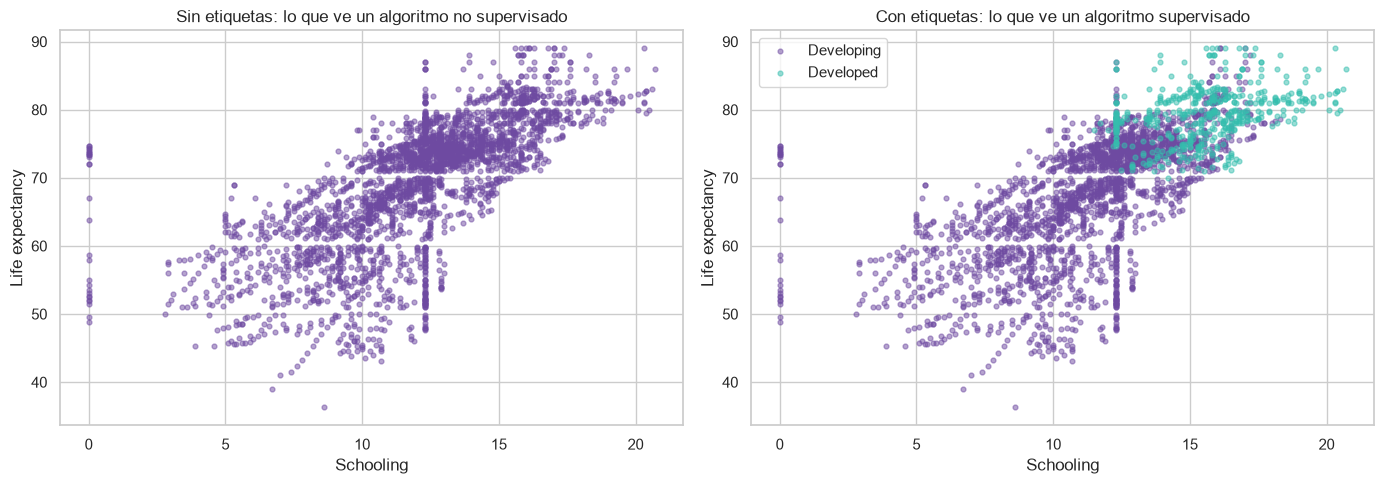

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df_limpio['Schooling'], df_limpio['Life expectancy'],
                s=12, alpha=0.5, color='#6E4AA1')
axes[0].set_title('Sin etiquetas: lo que ve un algoritmo no supervisado')
axes[0].set_xlabel('Schooling')
axes[0].set_ylabel('Life expectancy')

for estado, color in [('Developing', '#6E4AA1'), ('Developed', '#35BEAE')]:
    subset = df_limpio[df_limpio['Status'] == estado]
    axes[1].scatter(subset['Schooling'], subset['Life expectancy'],
                    s=12, alpha=0.5, color=color, label=estado)

axes[1].set_title('Con etiquetas: lo que ve un algoritmo supervisado')
axes[1].set_xlabel('Schooling')
axes[1].set_ylabel('Life expectancy')
axes[1].legend()

plt.tight_layout()
plt.show()

Son exactamente los mismos puntos. Lo único que cambia es la información que acompaña a cada uno, y eso alcanza para que el problema sea de una familia o de la otra.


## Parte 3: Tarea supervisada de regresión

**Pregunta:** ¿cuántos años de expectativa de vida podemos esperar en un país, dadas sus características de salud, educación y economía?

La respuesta es un número, así que estamos ante un **problema de regresión**. Por convención, a la matriz de características la llamamos `X` y al vector de etiquetas `y`.


In [12]:
X_reg = df_limpio[caracteristicas]
y_reg = df_limpio['Life expectancy']

print('X_reg:', X_reg.shape, '->', X_reg.shape[0], 'casos y', X_reg.shape[1], 'características')
print('y_reg:', y_reg.shape, '-> un valor numérico por caso')
print()
print(y_reg.describe().round(2))

X_reg: (2938, 18) -> 2938 casos y 18 características
y_reg: (2938,) -> un valor numérico por caso

count    2938.00
mean       69.23
std         9.51
min        36.30
25%        63.20
50%        72.10
75%        75.60
max        89.00
Name: Life expectancy, dtype: float64


Mirar qué características se relacionan más con la etiqueta nos da una intuición de si el problema tiene solución con los datos que tenemos.


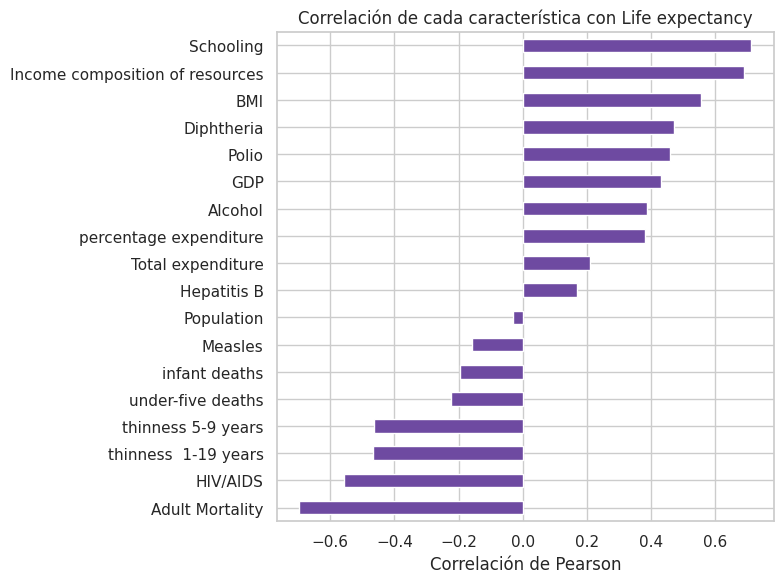

,0
Adult Mortality,-0.696
HIV/AIDS,-0.557
thinness 1-19 years,-0.468
thinness 5-9 years,-0.462
under-five deaths,-0.223
infant deaths,-0.197
Measles,-0.158
Population,-0.029
Hepatitis B,0.170
Total expenditure,0.209


In [12]:
correlaciones = X_reg.corrwith(y_reg).sort_values()

plt.figure(figsize=(8, 6))
correlaciones.plot(kind='barh', color='#6E4AA1')
plt.title('Correlación de cada característica con Life expectancy')
plt.xlabel('Correlación de Pearson')
plt.tight_layout()
plt.show()

correlaciones.round(3)

`Schooling` y `Income composition of resources` se mueven junto con la expectativa de vida, y `Adult Mortality` y `HIV/AIDS` lo hacen en sentido contrario. Son relaciones esperables, y nos dicen que el dataset tiene señal para el problema que planteamos.


## Parte 4: Tarea supervisada de clasificación

**Pregunta:** ¿podemos anticipar si un país está clasificado como desarrollado o en desarrollo a partir de sus indicadores?

La respuesta ahora es una categoría, así que el problema es de **clasificación**. Cambia `y`, y de paso cambia `X`: la expectativa de vida, que antes era la etiqueta, ahora pasa a ser una característica más.


In [13]:
X_clf = df_limpio[caracteristicas + ['Life expectancy']]
y_clf = df_limpio['Status']

print('X_clf:', X_clf.shape, '->', X_clf.shape[1], 'características')
print('y_clf:', y_clf.shape, '-> una categoría por caso')
print()
print(y_clf.value_counts())
print()
print((y_clf.value_counts(normalize=True) * 100).round(1))

X_clf: (2938, 19) -> 19 características
y_clf: (2938,) -> una categoría por caso

Status
Developing    2426
Developed      512
Name: count, dtype: int64

Status
Developing    82.6
Developed     17.4
Name: proportion, dtype: float64


Acá aparece algo que ya nombramos en la Clase 5: el **desbalance de clases**. Una categoría representa más del 80 por ciento de los casos. No es un error del dataset, pero condiciona cómo vamos a evaluar el modelo más adelante, en la Clase 15.


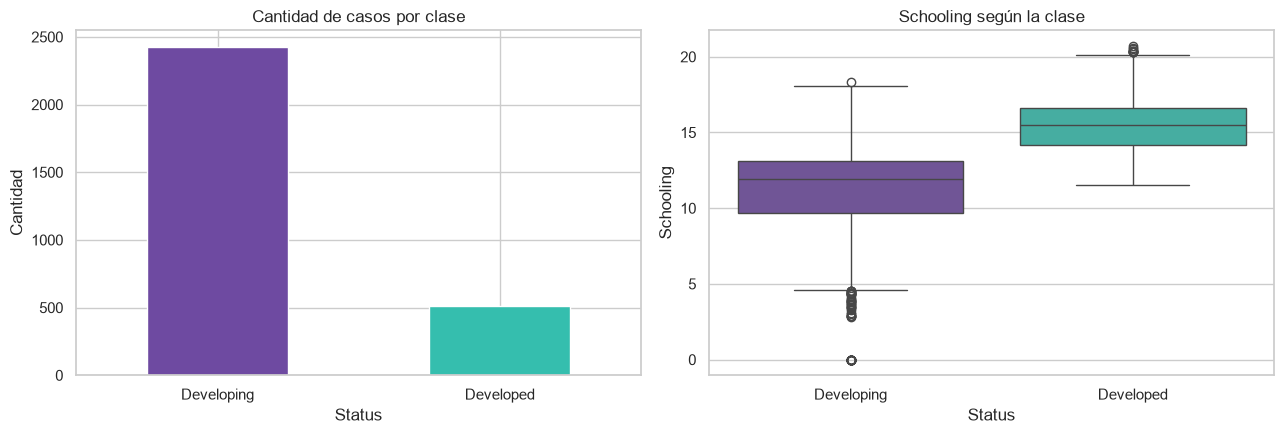

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

y_clf.value_counts().plot(kind='bar', ax=axes[0], color=['#6E4AA1', '#35BEAE'])
axes[0].set_title('Cantidad de casos por clase')
axes[0].set_ylabel('Cantidad')
axes[0].tick_params(axis='x', rotation=0)

sns.boxplot(data=df_limpio, x='Status', y='Schooling', ax=axes[1],
            palette=['#6E4AA1', '#35BEAE'], hue='Status', legend=False)
axes[1].set_title('Schooling según la clase')

plt.tight_layout()
plt.show()

El boxplot muestra que las dos clases se separan bastante bien con una sola característica. Cuando eso pasa, el problema de clasificación es prometedor.


## Parte 5: Tarea no supervisada de agrupamiento

**Pregunta:** sin decirle a nadie qué es un país desarrollado, ¿se forman grupos naturales entre los países según sus indicadores?

Acá no hay `y`. Tenemos solamente `X`, y le pedimos al algoritmo que encuentre estructura por su cuenta. Es lo que vamos a ver en el Módulo VI con clustering, PCA y SVD.


In [15]:
X_no_sup = df_limpio[['Schooling', 'Income composition of resources',
                      'Adult Mortality', 'GDP']]

print('X_no_sup:', X_no_sup.shape)
print('Etiquetas disponibles: ninguna')
X_no_sup.head()

X_no_sup: (2938, 4)
Etiquetas disponibles: ninguna


,Schooling,Income composition of resources,Adult Mortality,GDP
0,10.1,0.479,263.0,584.259210
1,10.0,0.476,271.0,612.696514
2,9.9,0.470,268.0,631.744976
3,9.8,0.463,272.0,669.959000
4,9.5,0.454,275.0,63.537231


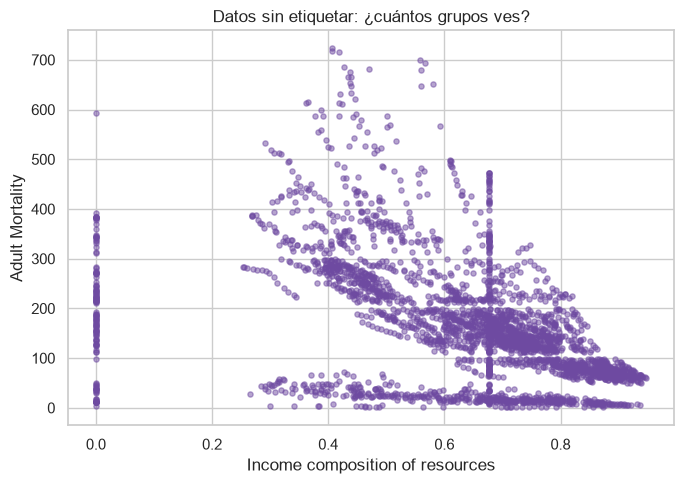

In [16]:
plt.figure(figsize=(7, 5))
plt.scatter(X_no_sup['Income composition of resources'],
            X_no_sup['Adult Mortality'],
            s=14, alpha=0.5, color='#6E4AA1')
plt.title('Datos sin etiquetar: ¿cuántos grupos ves?')
plt.xlabel('Income composition of resources')
plt.ylabel('Adult Mortality')
plt.tight_layout()
plt.show()

Este es el punto de partida de un algoritmo no supervisado. Notá que ni siquiera sabemos cuántos grupos hay: eso también es parte del problema, y lo vamos a discutir cuando lleguemos a K-Means en la Clase 20.


## Parte 6: Cómo elijo el algoritmo

Juntamos todo lo de la clase en una sola tabla. El camino siempre es el mismo: primero la **tarea**, después la **información** con la que contamos, y recién ahí el **algoritmo**.


In [17]:
resumen = pd.DataFrame([
    {'Pregunta': '¿Cuántos años de expectativa de vida?',
     'Etiqueta': 'Life expectancy (numérica)',
     'Aprendizaje': 'Supervisado',
     'Problema': 'Regresión'},
    {'Pregunta': '¿El país es desarrollado o en desarrollo?',
     'Etiqueta': 'Status (categórica)',
     'Aprendizaje': 'Supervisado',
     'Problema': 'Clasificación'},
    {'Pregunta': '¿Se forman grupos naturales de países?',
     'Etiqueta': 'No hay',
     'Aprendizaje': 'No supervisado',
     'Problema': 'Agrupamiento'},
])

resumen

,Pregunta,Etiqueta,Aprendizaje,Problema
0,¿Cuántos años de expectativa de vida?,Life expectancy (numérica),Supervisado,Regresión
1,¿El país es desarrollado o en desarrollo?,Status (categórica),Supervisado,Clasificación
2,¿Se forman grupos naturales de países?,No hay,No supervisado,Agrupamiento


Podemos escribir esa misma lógica como una función. No reemplaza el criterio de quien analiza, pero ordena la decisión.


In [17]:
def tipo_de_problema(datos, columna_objetivo=None, umbral_categorias=10):
    """Sugiere el tipo de tarea de Machine Learning a partir de la columna objetivo."""
    if columna_objetivo is None:
        return 'Aprendizaje no supervisado: no hay variable objetivo.'

    objetivo = datos[columna_objetivo]
    es_numerica = pd.api.types.is_numeric_dtype(objetivo)
    categorias = objetivo.nunique()

    if es_numerica and categorias > umbral_categorias:
        return f'Aprendizaje supervisado, regresión: {columna_objetivo} es numérica y continua.'

    return (f'Aprendizaje supervisado, clasificación: '
            f'{columna_objetivo} toma {categorias} valores distintos.')


print(tipo_de_problema(df_limpio, 'Life expectancy'))
print(tipo_de_problema(df_limpio, 'Status'))
print(tipo_de_problema(df_limpio, None))

Aprendizaje supervisado, regresión: Life expectancy es numérica y continua.
Aprendizaje supervisado, clasificación: Status toma 2 valores distintos.
Aprendizaje no supervisado: no hay variable objetivo.


Un caso para pensar: `Year` es numérica y toma muchos valores, así que la función la trataría como regresión. Sin embargo, predecir el año de una fila no responde ninguna pregunta útil. La función mira la forma del dato, no el sentido del problema. Esa parte siempre queda de nuestro lado.


In [ ]:
print(tipo_de_problema(df_limpio, 'Year'))

## Parte 7: Ejercicio para las salas de Zoom

Trabajamos en grupos con uno de los dos datasets que siguen. La consigna es la misma para los dos.

1. Cargá el dataset y mirá qué columnas tiene.
2. Escribí **una pregunta concreta** que se pueda responder con esos datos.
3. Decidí si la tarea es **supervisada** o **no supervisada**, y justificá por qué.
4. Si es supervisada, indicá cuál sería la **variable objetivo** y si el problema es de **regresión** o de **clasificación**.
5. Armá `X` y, si corresponde, `y`, y mostrá las dimensiones de cada uno.
6. Preparate para contarle al resto del curso la pregunta que eligieron y la decisión que tomaron.


### Opción A: clientes de un shopping

`clientes_mall.csv` tiene datos de clientes de un centro comercial: edad, ingreso anual y un puntaje de gasto.


In [19]:
clientes = pd.read_csv('C:/Users/gn_d4/Documents/GERMÁN/DATA SCIENCE/DATA SCIENCE/NOTEBOOKS/NOTEBOOKS 2026/clientes_mall.csv')
clientes.head()

,Unnamed: 0,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,0,1.0,Male,19.0,15.0,39.0
1,1,2.0,NaN,21.0,15.0,81.0
2,2,3.0,Female,20.0,16.0,6.0
3,3,4.0,Female,23.0,16.0,77.0
4,4,5.0,NaN,31.0,17.0,40.0


In [ ]:
# Escribí acá tu respuesta a los puntos 1 a 5


### Opción B: publicaciones de venta de autos usados

`venta_autos.csv` tiene avisos de venta de autos usados, con precio, marca, modelo, kilometraje y tipo de combustible, entre otras columnas.


In [ ]:
autos = pd.read_csv('venta_autos.csv')
autos.head()

In [ ]:
# Escribí acá tu respuesta a los puntos 1 a 5


### Para cerrar

Antes de terminar la clase, cada grupo comparte:

- la pregunta que eligió,
- el tipo de aprendizaje y el tipo de problema,
- una dificultad que haya aparecido al armar `X` y `y`.

En la **Clase 12** volvemos sobre estas mismas decisiones, pero ya entrenando los primeros modelos de regresión y clasificación con la Notebook 16.
